# Droplet Generation System. Hydraulic part

# Problem setup

See actual problem setup description in ECC2024

## Piston Dynamics

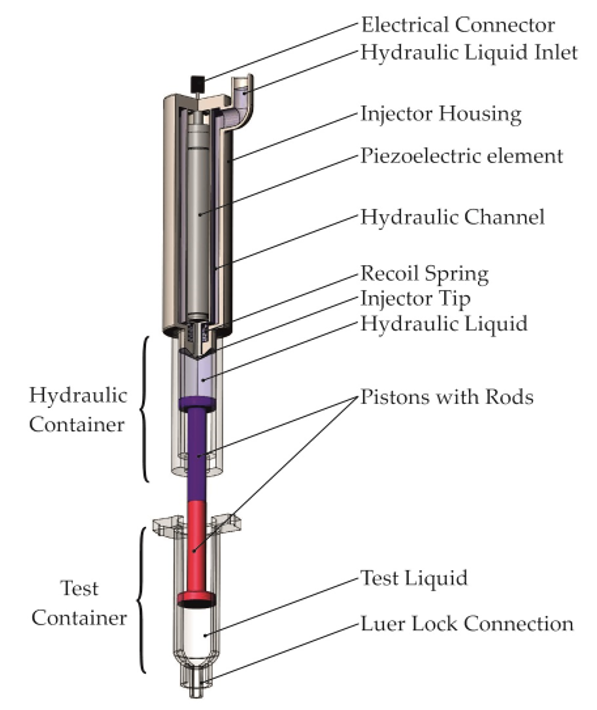

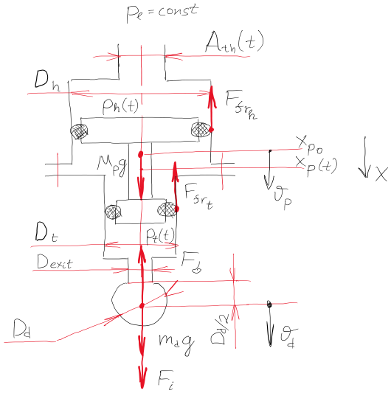

Piston moves by the hydraulic and friction forces action:
$$
    m_p\ddot{x_p} = m_pg + F_h - F_{fr},
$$
### Hydraulic force $F_h$:
$$
    F_h = p_h A_h - p_t A_t,
$$
where hydraulic container pressure, according to the Darcy-Weisbach equation and relationship of the lateral surface area of the throttle "cylinder" to the position of the spool (**action**) $A_{th}(t) = \pi D_{th} x_{th}(t)$:
$$
    p_h = p_l - \frac{\zeta_{th}\rho_h D_h^4}{32D_{th}^2}\left(\frac{\dot{x_p}}{x_{th}}\right)^2
$$
test container pressure (according to the Darcy-Weisbach equation):
$$
    p_t = p_{atm} + \frac{\zeta_{exit}\rho_t D_t^4}{2D_{exit}^4}\dot{x_p}^2
$$

Hydraulic/Test container area:
$$
    A_{h,t}=\frac{\pi D_{h,t}^2}{4}
$$

$p_l$ - pressure of the hydraulic liquid before throttling;
$p_{atm}$ - ambient environment (atmosphere) pressure;
$\zeta_{th}, \zeta_{exit}$ - hydraulic loss coefficients at throttle and at syringe exit respectively;
$\rho_h, \rho_t$ - densities of the hydraulic and test containers liquids

### Friction $F_{fr}$
Friction can be considered both by a stribeck curve or mechanical efficiency.
Let us use a mechanical efficiency approach:
$$
    F_{fr} = \max{(F_C, (1-\eta)F_h)},
$$

where $\eta$ - mechanical efficiency;
Coulomb friction force:
$$
    F_C = p_C\cdot\max{(A_h, A_t)}
$$
$p_C$ - pressure difference, which is necessary to overcome the dry friction

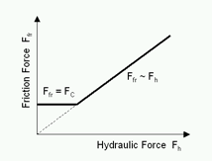

## State dynamics function

Movement starts when acting force larger than friction force.

Let us use $x_{th}, x_{p}, v_{p}$ in $\mu m$. Other values are in SI.
$$
    \begin{aligned}
        &   \dot{x_p} = v_p,
        \\
        &   \dot{v_p} = \begin{cases} g + \frac{1}{m_p}[F_h(x_p, v_p, x_{th}) + F_{fr}(v_p, F_h)], \text{ if } [|v_p| > 0] \text{ or } [|F_h + m_pg| > |F_{fr}|]\\
                        0, \text{ otherwise }\end{cases}
    \end{aligned}
    \qquad x_{th} \in [0, x_{th}^{max}],
$$

where:

$$
    \begin{aligned}
        & F_h(x_p, v_p, x_{th}) = A_h p_h(x_p, v_p, x_{th}) - A_t p_t(x_p, v_p) \\
        
        &\qquad \text {where: } \\

        &\qquad p_h(x_p, v_p, x_{th}) = \begin{cases}
            \max{\left(\left[p_l - \frac{v_p|v_p|}{x_{th}^2}\frac{\zeta_{th}\rho_h D_h^4}{32D_{th}^2} \right], p_{sv} \right)}, \text{ if } [x_{th} > 0] \\

            \max{\left(\left[p_h\vert_{x_{th}>0}+(\frac{x_p\vert_{x_{th}>0}}{x_p}-1)\frac{1}{\beta_{V_h}}\right], p_{sv}\right)}, \text{ otherwise } \\
        \end{cases} \\
        &\qquad p_t(x_p, v_p) = p_{atm} + sign(x_p - x_{p0})\cdot \min{\left(\frac{4\sigma_t}{D_{exit}}, \left|\frac{x_p - x_{p0}}{x_p}\right| \frac{1}{\beta_{V_t}} \right)} + v_p|v_p|\frac{\zeta_{exit} \rho_t D_t^4}{2D_{exit}^4 \cdot 10^{12}} \\
        
        & F_{fr}(v_p, F_h) = \begin{cases} 
            -sign(v_p)\cdot \max{[p_C A_{max}, (1-\eta) F_h]}, \text{ if } [|v_p|>0] \\
            
            -sign(F_h + m_pg)\cdot p_C A_{max}, \text{ otherwise } \\
        \end{cases}
    \end{aligned}
$$

where $A_{max} = \max{(A_h, A_t)}$; $p_l > p_{atm}$; $p_{sv}$ - saturated vapor pressure of liquid ($2340~Pa$ for water), $\beta_V$ - liquid volume compression coefficient ($0.49\cdot 10^{-9}~Pa^{-1}$ for water); 
$p_h\vert_{x_{th}>0},~x_p\vert_{x_{th}>0}$ - last hydraulic pressure and piston position when $x_{th}$ was more than 0;
$\sigma_t$ - surface tension of the test liquid

The starting possition is:
$$
    \begin{aligned}
        & x_{p0} = x_p(0) = 10^{3} [\mu m] \\
        & v_p(0) = 0 [\mu m/s]\\
    \end{aligned}
$$

**Note**: It is important to add, that the throttle position cannot be changed immediately. 
Thus, to model the throttle position changing let us add one more state with some constant changing speed:
$$
    \begin{aligned}
        & \text{while } x_{th} \neq x^{act}_{th}: \\
        &\qquad \dot{x_{th}} = sign(x^{act}_{th}-x_{th}) \cdot v^{max}_{th}\\
    \end{aligned}
$$

## Observations

System diameters are in $m$, drop diameter and jet length are in $mm$. Jet speed is in $\frac{mm}{s}$

Let us assume, that we can measure only the length of the test liquid jet $l_{jet}$ and it's velocity $v_{jet}$.

According to the existing researches [[1](https://doi.org/10.1007/s00348-003-0629-6), [2](https://doi.org/10.1201/9781420040470)], liquid drop will be formed, if $\max(l_{jet})>l_{crit}$, where:
$$
    \begin{aligned}
        & \frac{l_{crit}}{D_{exit}} = 19.5\cdot 10^3~We^{0.5}(1 + 3Oh)^{0.85} \\
        & We = \frac{\rho_t v_j^2 D_{exit}}{10^{6} \sigma_t} \\
        & Oh = \frac{\sqrt{We}}{Re} \\
        & Re = \frac{\rho_t v_j D_{exit}}{10^{3} \mu_t}, \\
    \end{aligned}
$$

where $v_j$ - jet velocity. 
Empirically it was estimated as $200 \frac{mm}{s}$.
$\mu_t$ - dynamic viscosity of the test liquid.

Droplet diameter [mm] can be estimated as follows:
$$
    \frac{D_{d}}{D_{exit}} = 10^3 (1.5\pi\sqrt{2 + 3Oh})^{1/3}
$$

## Running cost function

Our formal goal of control:
$$
    \begin{aligned}
    & l_{jet} \to l_{crit} & v_{jet} \to 0~(\text{when } l_{jet}\geq l_{crit})\\
    & \text{ where: } l_{jet} = 10^{-3}\frac{D^2_t}{D^2_{exit}} (x_p - x_{p0}) \\
    & v_{jet} = 10^{-3}\frac{D^2_t}{D^2_{exit}} v_p \\
    \end{aligned}
$$

If $l_{jet} < l_{crit}$ droplet will not detach.
If $l_{jet} > l_{crit}$ droplet will detach, but with satellites.

Let us achieve this using a stochastic control policy defined by a model $\rho^{\theta}(x^{act}_{th}|l_{jet}, v_{jet})$ with optimizing running cost $r$. $\rho^{\theta}$ will be treated as a probability distribution: $x^{act}_{th} \sim \rho^{\theta}(\bullet|l_{jet}, v_{jet})$

Let us penalize policy by a running cost function:
$$
    r(l_{jet}, v_{jet}) = \left(1 - \frac{l_{jet}}{l_{crit}} \right)^2 - sign\left(1 - \frac{l_{jet}}{l_{crit}}\right) v_{jet} |v_{jet}|
$$


**NOTE:** see implementation explanation in [Monte Carlo Simulation Scenario](#Monte-Carlo-Simulation-Scenario)

# NN policy model

The policy model will be taken as:

$$
    \rho^{\theta}(x^{act}_{th}|l_{jet}, v_{jet}) = \mathsf{pdf}_{
        \mathcal{N}\left(\lambda \mu_{\theta}(y) + \beta, \lambda^2\sigma^2\right)
    }(u)
$$

where $ \mathsf{pdf}_{\mathcal{N}(\bullet_1, \bullet_2)} $ refers to the normal probability density with mean $\bullet_1$ and (co)variance $\bullet_2$, $\beta = \frac{U_{\min} + U_{\max}}{2}$, $\lambda = \frac{U_{\max} - U_{\min}}{2}$ and
the $\mu_{\theta}(\cdot)$ is a perceptron with weights $\theta$:

$$
    \mu_{\theta}(y): y \to \text{Linear} \to \text{LeakyReLU} \to ... \to \text{Linear} \to (1 - 3\sigma) \tanh\left(\frac{\cdot}{L}\right)
$$

**Remarks:**
- Hyperparameter $L$ is used to tune model (more important at first iterations, since make weights changing smaller)
- Last activation layer leads to $\mu_{\theta}(y) \in [-1 + 3\sigma, 1 - 3\sigma]$. Since operation $\lambda\cdot[\bullet]+\beta$ transforms $[-1, 1]$ to $[U_{min}, U_{max}]$, the policy $\rho^{\theta}(x^{act}_{th}|l_{jet}, v_{jet})$ samples actions that are within action bounds $[U_{\min}, U_{\max}]$ with propability greater than 99.86% by [$3\sigma$-rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule).
If actions are sampled out of this bounds, we clamp it to $[U_{min}, U_{max}]$.
- Let us choose $[U_{\min}, U_{\max}]$ in such a way, that $U_{\min} < (x^{\min}_{th} = 0)$, $U_{\max} > (x^{\max}_{th} = 20.0 \mu m)$. System limits actions: $u = x^{\min}_{th},\text{ if } u < x^{\min}_{th}$; $u = x^{\max}_{th},\text{ if } u > x^{\max}_{th}$. This approach allows to consider negative actions as fully closing of the throttle and actions larger than $x^{\max}_{th}$ as fully opening of the throttle. It is important, since policy must learn to close throttle after reaching the critical jet length.

# Policy

Let us calculate **surrogate** objective value:
$$
 \frac{1}{M}
    \sum_{j=1}^{M}
    \sum_{k=0}^{N-1}
        \left(\sum_{k'=k}^{N-1} \gamma^{k'} r\left(y_{k'}^j, u_{k'}^j\right) - b^i_k\right)
        \ln\rho^\theta(u_k^j \mid y_k^j)
$$

Notation in code:

1. `N_episodes` is $M$
2. `observations_actions` is the batch of $(y_{k}^j, u_{k}^j)$ with shape ($M\times N$, `dim_observation` + `dim_action`).

3. `tail_total_objectives` is the batch of $\sum_{k'=k}^{N-1} \gamma^{k'} r\left(y_{k'}^j, u_{k'}^j\right)$ with shape ($M\times N$,)
4. `baselines` is the batch of baselines $b_k^i$ with shape  ($M\times N$,)

Let us store data in batch in the following order
$$
    \begin{matrix}
        \texttt{observations}\_\texttt{actions} & \texttt{tail}\_\texttt{total}\_\texttt{objectives} & \texttt{baselines} \\
        y_0^1, u_0^1 & \sum_{k'=0}^{N-1} \gamma^{k'} r\left(y_{k'}^1, u_{k'}^1\right) & b_0^i\\
        y_1^1, u_1^1 & \sum_{k'=1}^{N-1} \gamma^{k'} r\left(y_{k'}^1, u_{k'}^1\right) & b_1^i \\
        y_2^1, u_2^1 & \sum_{k'=2}^{N-1} \gamma^{k'} r\left(y_{k'}^1, u_{k'}^1\right) & b_2^i\\
        \vdots & \vdots & \vdots\\
        y_{N-1}^1, u_{N-1}^1 & \sum_{k'=N-1}^{N-1} \gamma^{k'} r\left(y_{k'}^1, u_{k'}^1\right) & b_{N-1}^i\\
        y_0^2, u_0^2 & \sum_{k'=0}^{N-1} \gamma^{k'} r\left(y_{k'}^2, u_{k'}^2\right) & b_0^i\\
        y_1^2, u_1^2 & \sum_{k'=1}^{N-1} \gamma^{k'} r\left(y_{k'}^2, u_{k'}^j\right) & b_1^i\\
        y_2^2, u_2^2 & \sum_{k'=2}^{N-1} \gamma^{k'} r\left(y_{k'}^2, u_{k'}^2\right) & b_2^i\\
        \vdots & \vdots & \vdots \\
        y_{N-1}^2, u_{N-1}^2 & \sum_{k'=N-1}^{N-1} \gamma^{k'} r\left(y_{k'}^2, u_{k'}^3\right) & b_{N-1}^i\\
        y_0^3, u_0^3 & \sum_{k'=0}^{N-1} \gamma^{k'} r\left(y_{k'}^3, u_{k'}^3\right) & b_0^i\\
        \vdots & \vdots & \vdots \\
        \vdots & \vdots & \vdots \\
        y_{N-1}^M, u_{N-1}^M & \sum_{k'=N-1}^{N-1} \gamma^{k'} r\left(y_{k'}^M, u_{k'}^M\right) & b_{N-1}^i
    \end{matrix}
$$

# Monte Carlo Simulation Scenario

## Implementation

The code is organized as follows. The **main loop** (see below) is implemented in `MonteCarloSimulationScenario` which starts REINFORCE learning procedure via `run` method. During the main loop all observations, actions, running costs for every episode and step are collected in `IterationBuffer` object which is constructed in `PolicyREINFORCE`. After every iteration `MonteCarloSimulationScenario` calls `REINFORCE_step` method  which does gradient descent step via calling the `optimize` method that is implemented in `Optimizer`.

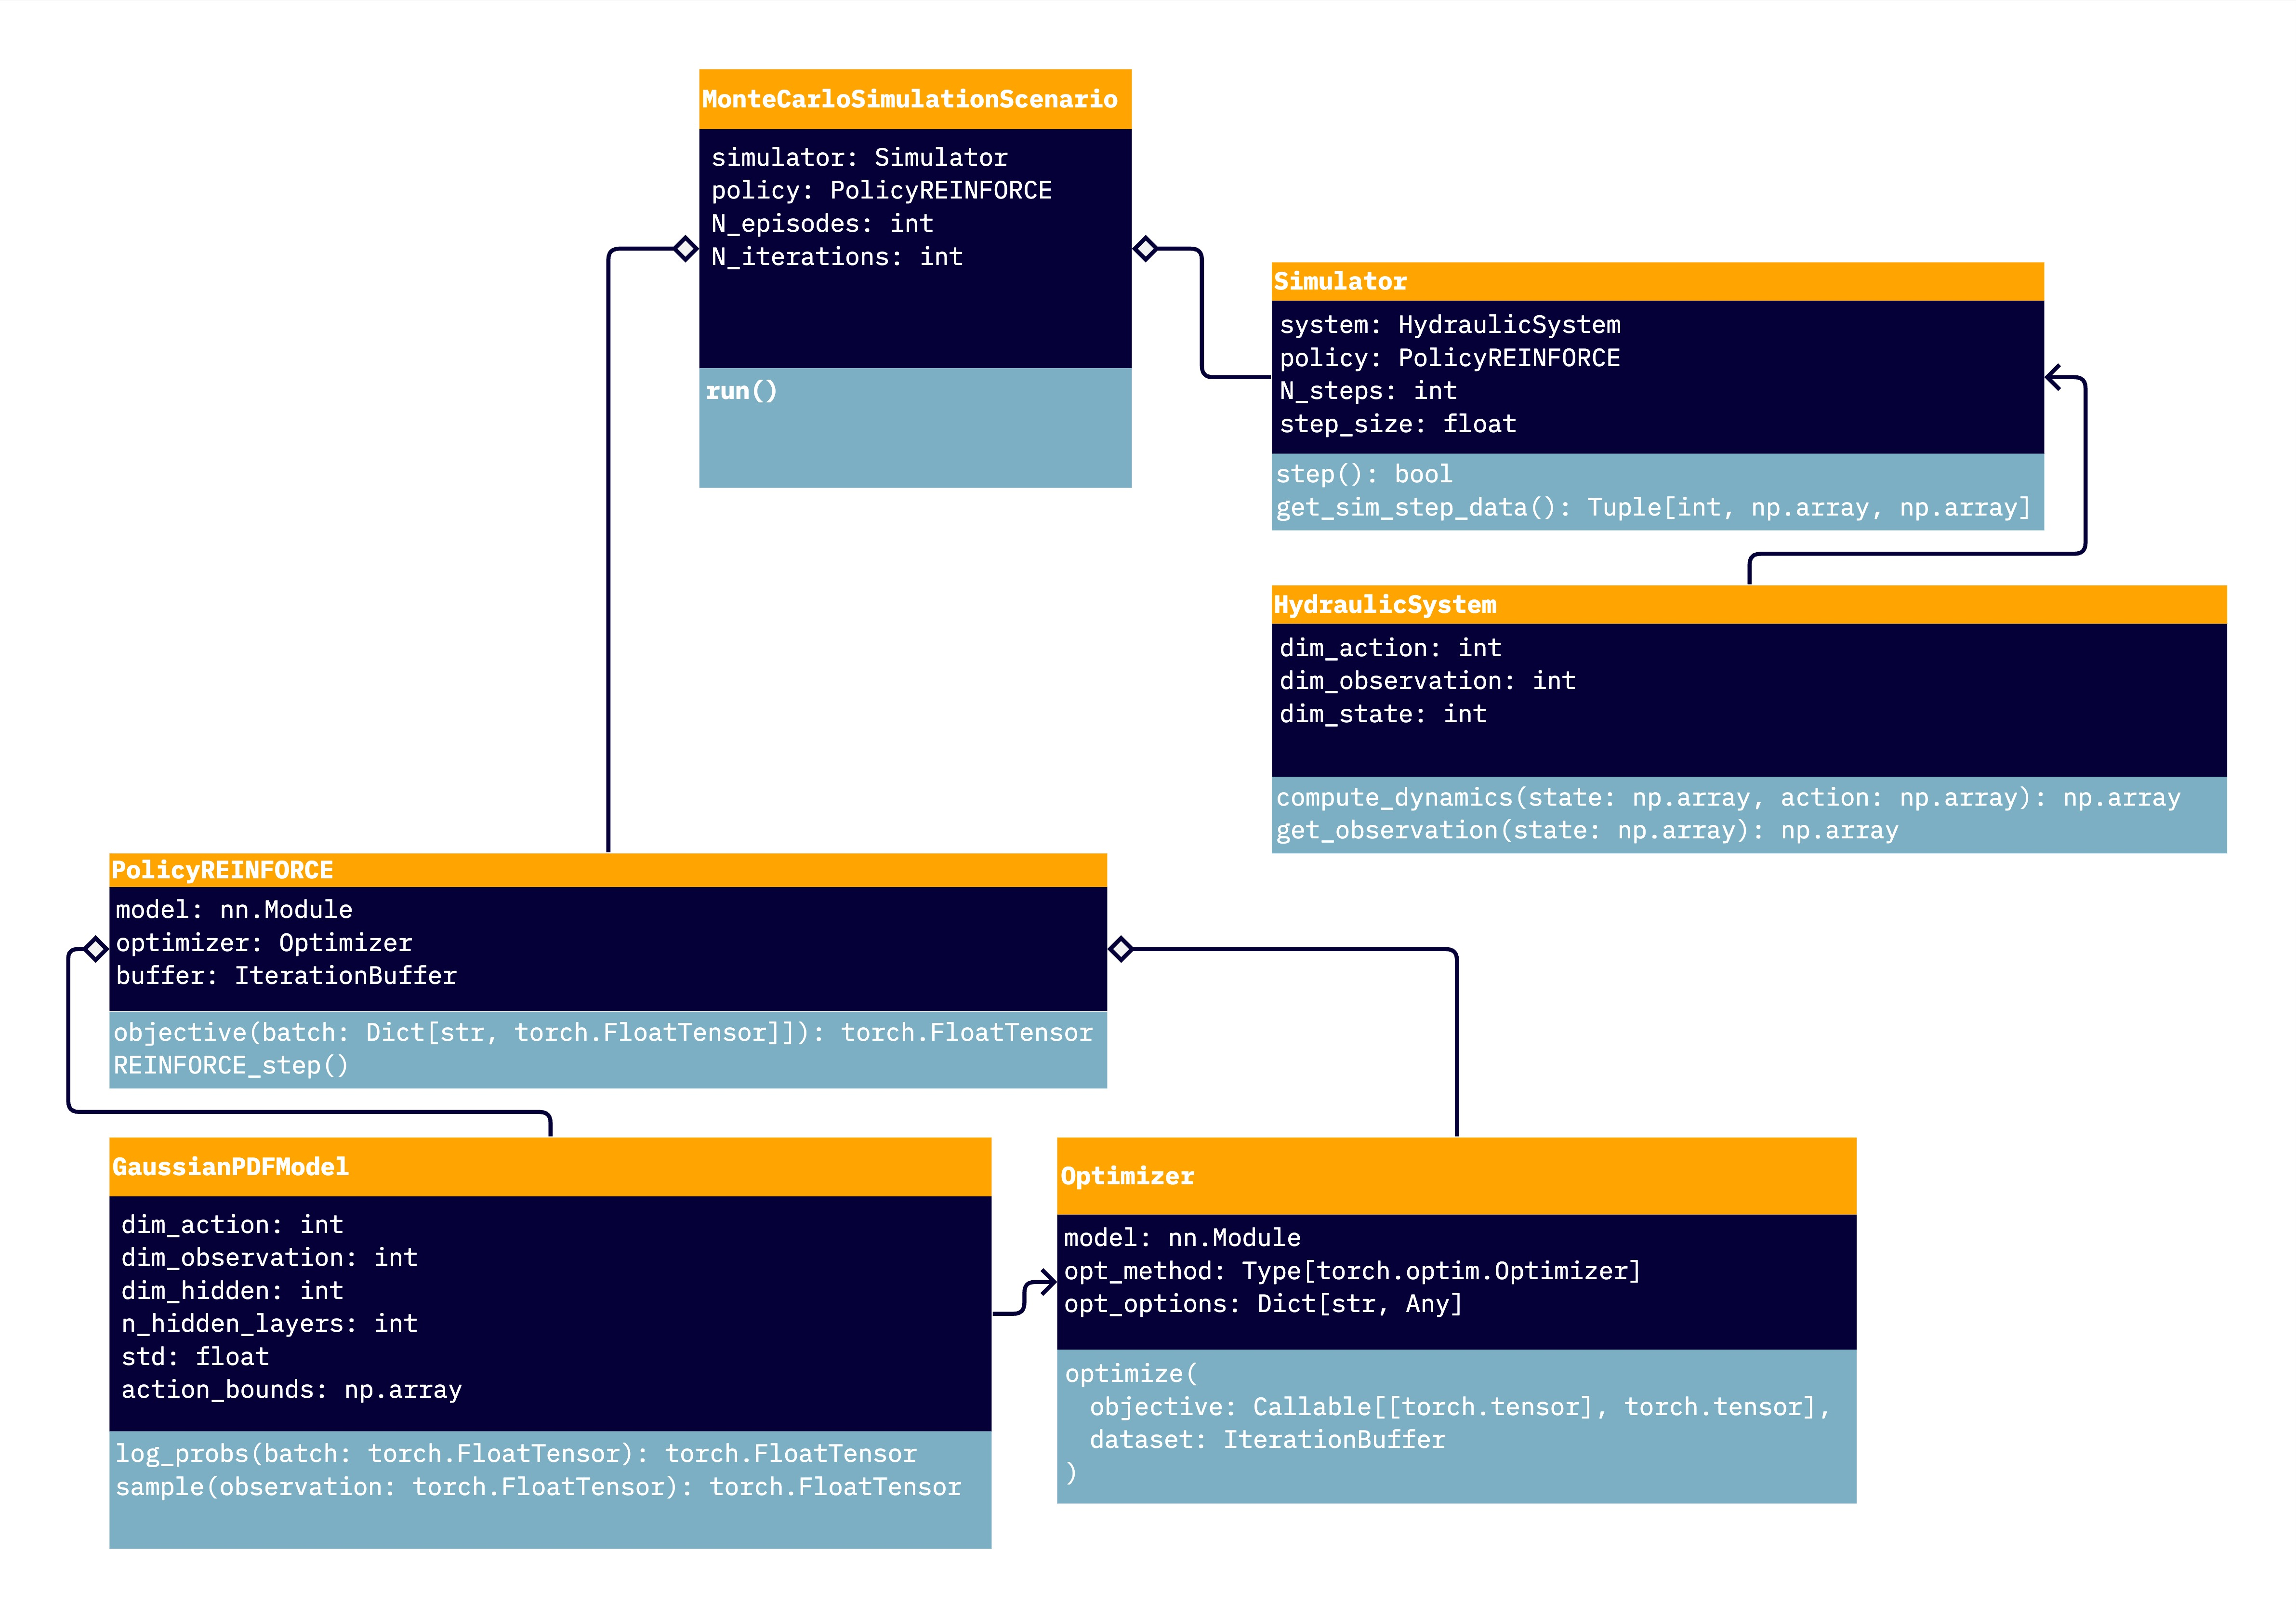



## Main loop:
This scenario is based on the **REINFORCE algorithm**

General formula:

$$
  \boxed{
    \begin{array}{l}
    \hphantom{~}
    \\
    \theta_{i+1} \gets\theta_{i} - \alpha_i \mathbb{E}\left[ \sum_{k = 0}^{N-1} \left( \sum_{k'=k}^{N-1} \gamma^{k'}r(Y_{k'}, U_{k'}) - B_k \right) \nabla_{\theta} \ln\rho^{\theta}(U_k \mid Y_k)\big|_{\theta=\theta^i}\right]
    \\
    \hphantom{~}
    \end{array}
  }.
$$
where $B_k$ is the baseline --- a random variable independent on $(Y_k, U_k)$ (or in general case independent on $U_k$ conditioned on $Y_k$).
 - Initialize baseline for the 1st iteration: $b^1 = 0.$

- **for** $i$ in $\{1, \dots, \mathcal I\}$: ($\mathcal I$ is the number of iterations).
Every iteration consists of $M$ episodes, i.e., Monte-Carlo runs.
  >**for** $j$ in $\{1, \dots, M\}$: ($j$ is the number of episode, i.e., the number of a Monte-Carlo run)
  >>
  >> **for** $k$ in $\{0, \dots, N-1\}$: ($k$ is the number of step inside an episode)
  >>>
  >>> - obtain observation $y_k^j$ from the system
  >>> - sample action $u_k^j$ from $\rho^{\theta}(u_k^j \mid y_k^j)$
  > - compute a baseline for the next iteration, e.g., as previous means of tail objectives (a common choice):
  $$
      b^{i + 1}_k \gets\frac{1}{M} \sum_{j=1}^M \sum_{k'=k}^{N-1} \gamma^{k'} r(y_{k'}^j, u_{k'}^j)
  $$ (it is our approach you can put any baseline you want)
  > - perform a gradient step:
  $$
      \theta_{i+1}
      \gets
      \theta_i
      -
      \alpha_i
      \frac{1}{M}
      \sum_{j=1}^{M}
      \sum_{k=0}^{N-1}
          \left(\sum_{k'=k}^{N-1} \gamma^{k'} r\left(y_{k'}^j, u_{k'}^j\right) - b^i_k\right)
          \nabla_\theta \ln\rho^\theta(u_k^j \mid y_k^j)\big|_{\theta=\theta^i}
  $$

# Run simulation and fit REINFORCE

In [1]:
import numpy as np
import torch
import random
import os

from src.system import HydraulicSystem
# from src.simulator import Simulator
from src.simulator_casadi import create_simulator
from src.policy import PolicyREINFORCE, GaussianPDFModel, Optimizer
from src.scenario import MonteCarloSimulationScenario

from IPython.display import clear_output

import regelum as rg

data_path = './data'
os.path.isdir(data_path)
%matplotlib inline

Initial state

In [2]:
# Define the initial state
p_atm = 1e5
# initial_state = np.array([1e3, 0, 0, p_atm, p_atm])
initial_state = rg.array([1e3, 0, 0, p_atm, p_atm])

## Set hyperparams

In [3]:
# SET HYPERPARAMS
# GaussianPDFModel Params
n_hidden_layers_policy = 1
dim_hidden_policy = 2
scale_factor_policy = 10.0
std_policy = 0.003  # Reduced from 0.005 for more stable learning
action_bounds_policy = np.array([[-20., 30]]) # These actions are expanded in comparison with real action

# Optimizer params
# opt_method_policy = torch.optim.Adam
opt_method_policy = torch.optim.Adam
opt_options_policy = dict(
    lr=3e-3,  # Reduced from 5e-3 for more stable convergence
    weight_decay=2e-4,  # Added back for better regularization
)

# MonteCarloSimulationScenario params
N_episodes = 10 # Increased from 5 for better stability
N_iterations = 150  # Reduced from 200 since we expect faster convergence
discount_factor = 1.0


SEED = 14
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

system = HydraulicSystem(
    init_state=initial_state,
    system_parameters_init = {
        "p_l_gauge": 1.5e5,
        "x_th_limits": (0., 20.),
        "freq_th": 500.0,
        "m_p": 20e-3,
        "D_th": 200e-6, # WAS 200e-6, then 5e-3
        "D_hydr": 20e-3,
        "D_work": 20e-3,
        "h_work_init": 1e3,
        "D_exit": 0.33e-3,
        "l_exit": 8.5e-3,
        "p_coulomb": 10e3, # WAS 10e3, then 1e3
        "eta": 0.70,
        "zeta_th": 5.0, # WAS 5.0, then 0.1
        "rho_hydr": 1e3,
        "rho_work": 1e3,
        "beta_v_hydr": 0.49e-9,
        "beta_v_work": 0.49e-9,
        "sigma_work": 73e-3,
        "mu_work": 1.0e-3,
        "v_j": 200.,
        # "jet_length_std": 2e-2, # Was 5e-2
        # "jet_velocity_std": 5e-3, # Was 1e-2
        "jet_length_std": 5e-2,
        "jet_velocity_std": 1e-2,
        "pressure_std": 0.,
        "p_atm": 1e5, # Atmosphere (ambient) pressure, Pa
        "g": 9.81, # gravity constant, m/s^2
    },
)

# Create CasADi simulator
simulator = create_simulator(
    simulator_type='casadi',
    system=system,
    N_steps=10,
    state_init=initial_state,
    integration_method='rk4',  # Change from 'collocation' to 'rk4'
    n_substeps=10000,
    use_symbolic=True
)

# model = GaussianPDFModel(
#     dim_observation=system.dim_observation,
#     dim_action=system.dim_inputs,
#     dim_hidden=dim_hidden_policy,
#     n_hidden_layers = n_hidden_layers_policy,
#     scale_factor=scale_factor_policy,
#     std=std_policy,
#     action_bounds=action_bounds_policy,
# )

# model = torch.load(
#     "models/model_policy_reinforce_less_frequency.pkl",
#     map_location='cpu',
# )

model = torch.load(
    "models/model_policy_reinforce_noise_opt.pkl",
    map_location='cpu',
)

# Convert model to double precision to match the system data type
# model = model.double()

optimizer = Optimizer(
    model=model,
    opt_method=opt_method_policy,
    opt_options=opt_options_policy,
)

policy = PolicyREINFORCE(model, optimizer, is_with_baseline=True)

scenario = MonteCarloSimulationScenario(
    simulator=simulator,
    policy=policy,
    N_episodes=N_episodes,
    N_iterations=N_iterations,
    discount_factor=discount_factor,
    root_data_path=data_path,
    seed=SEED,
)

# PRINT HYPERPARAMS
print(f'Policy (GaussianPDFModel) Perceptron')
print(f'action_bounds_policy [µm] = {action_bounds_policy}')
print(f'n_hidden_layers_policy = {n_hidden_layers_policy}')
print(f'dim_hidden_policy = {dim_hidden_policy}')
print(f'scale_factor_policy = {scale_factor_policy}')
print(f'std_policy = {std_policy}')
policy_params = sum(p.numel() for p in model.parameters())
print(f"Number of policy parameters: {policy_params}")
print()
print('Policy Optimizer')

print(f'opt_method_policy = {opt_method_policy}')
print(f'opt_options_policy = {opt_options_policy}')
print()
print('MonteCarloSimulationScenario')
print(f'N_episodes = {N_episodes}')
print(f'N_iterations = {N_iterations}')
print(f'discount_factor = {discount_factor}')

Policy (GaussianPDFModel) Perceptron
action_bounds_policy [µm] = [[-20.  30.]]
n_hidden_layers_policy = 1
dim_hidden_policy = 2
scale_factor_policy = 10.0
std_policy = 0.003
Number of policy parameters: 18

Policy Optimizer
opt_method_policy = <class 'torch.optim.adam.Adam'>
opt_options_policy = {'lr': 0.003, 'weight_decay': 0.0002}

MonteCarloSimulationScenario
N_episodes = 10
N_iterations = 150
discount_factor = 1.0


## Run simulation 

2025-09-02_180730_seed_14

Number of already conducted iterations 150


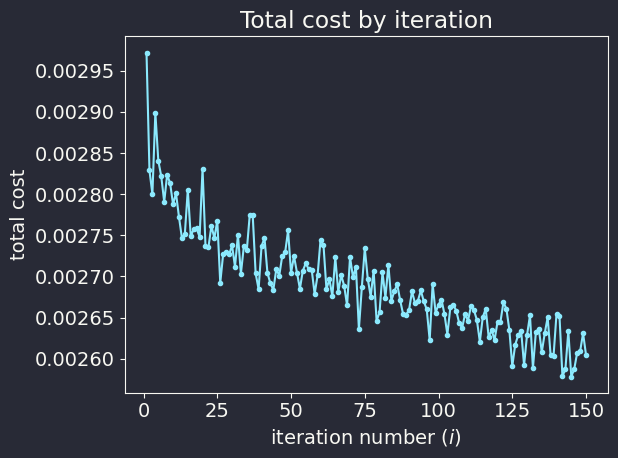

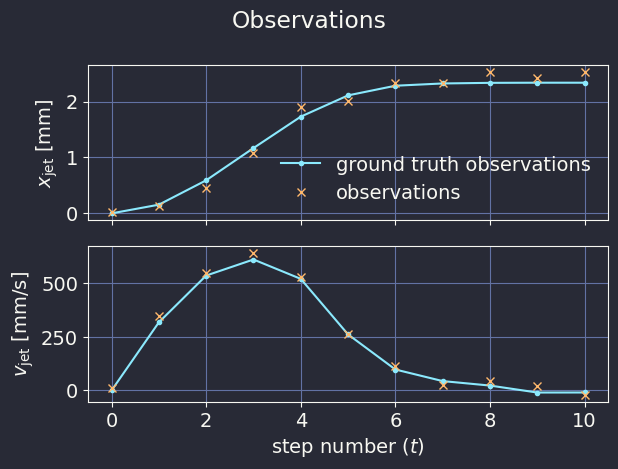

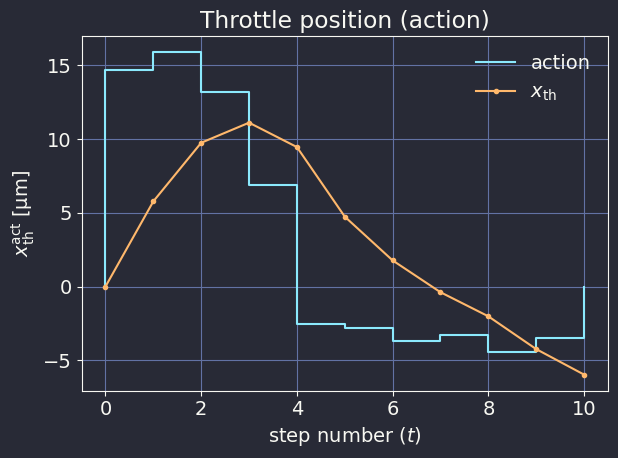

In [4]:
try:
    scenario.run()
    clear_output(wait=True)
except KeyboardInterrupt:
    print('Keyboard Interrupt')
    print('Stop iteration and plot obtained results')
except AssertionError as e:
    print('Get error:', e)
    print('Stop solve_ivp and plot obtained results')
finally:
    previous_learning_curve = scenario.learning_curve
    print(f'Number of already conducted iterations {len(previous_learning_curve)}')
    scenario.plot_data()

## Let us proceed the learning procedure

Number of already conducted iterations 300


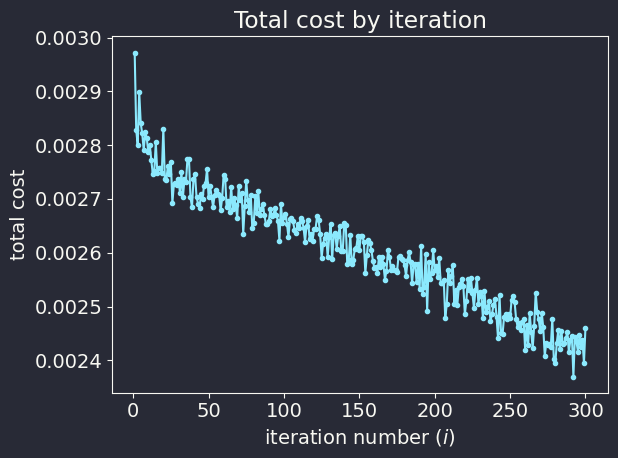

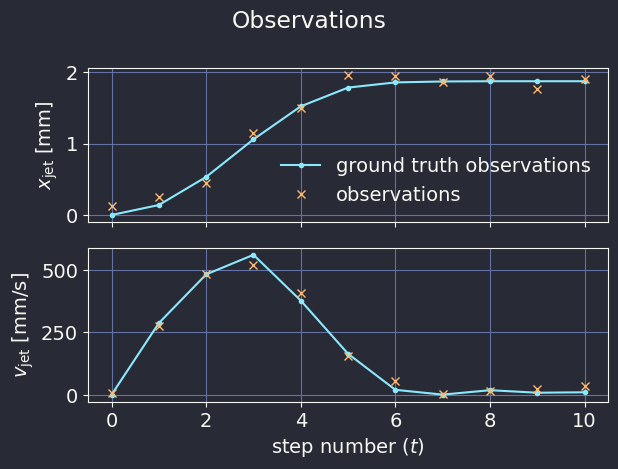

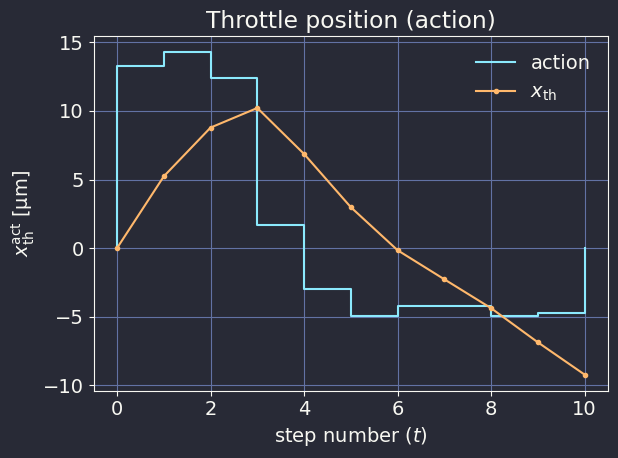

In [5]:
try:
    scenario.run()
    clear_output(wait=True)
except KeyboardInterrupt:
    print('Keyboard Interrupt')
    print('Stop iteration and plot obtained results')
except AssertionError as e:
    print('Get error:', e)
    print('Stop solve_ivp and plot obtained results')
finally:
    previous_learning_curve = scenario.learning_curve
    print(f'Number of already conducted iterations {len(previous_learning_curve)}')
    scenario.plot_data()

## Let us proceed the learning procedure

Number of already conducted iterations 450


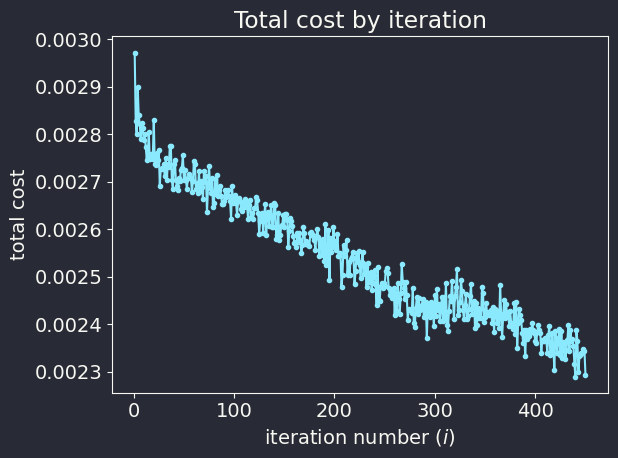

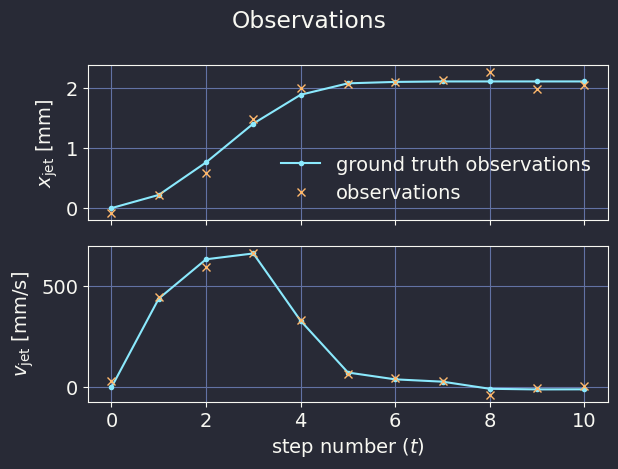

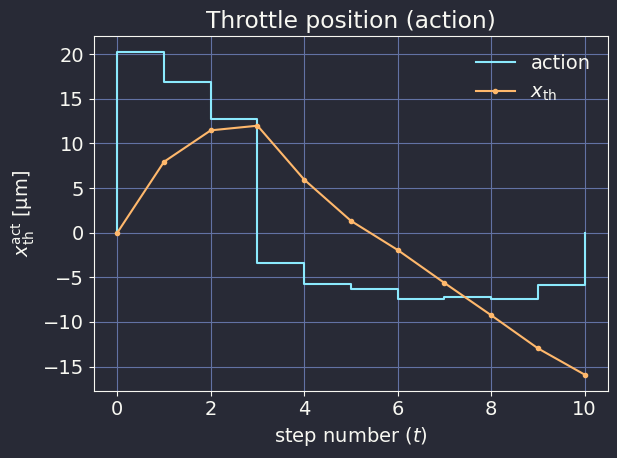

In [6]:
try:
    scenario.run()
    clear_output(wait=True)
except KeyboardInterrupt:
    print('Keyboard Interrupt')
    print('Stop iteration and plot obtained results')
except AssertionError as e:
    print('Get error:', e)
    print('Stop solve_ivp and plot obtained results')
finally:
    previous_learning_curve = scenario.learning_curve
    print(f'Number of already conducted iterations {len(previous_learning_curve)}')
    scenario.plot_data()

### Let us save obtained model

In [7]:
torch.save(model, 'models/model_policy_reinforce_5_state_system__from_noise_opt.pkl')